### Instalasi Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import warnings
from pathlib import Path
import joblib
import json
warnings.filterwarnings("ignore")

## **LOAD DATA DAN PENGECEKAN DATA**

### load data

In [2]:
DATA_PATH = "diabetes.csv"
data = pd.read_csv(DATA_PATH)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


In [3]:
# cek jumlah duplikasi (opsional)
print("Jumlah baris duplikat:", data.duplicated().sum())

# hapus baris duplikat (berdasarkan semua kolom)
data = data.drop_duplicates().reset_index(drop=True)

print("Jumlah baris setelah hapus duplikat:", len(data))

Jumlah baris duplikat: 1256
Jumlah baris setelah hapus duplikat: 744


In [4]:
# Cek missing values dan nilai 0 dan data duplikasi
print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome dan Pregnancies)
fitur_dengan_nol = data.drop(['Outcome', 'Pregnancies'], axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
persentase_baris_nol = (total_baris_nol / len(data)) * 100
print(f"Total baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {persentase_baris_nol:.2f}%")


Nilai 0 pada setiap kolom:
Pregnancies: 112
Glucose: 5
BloodPressure: 34
SkinThickness: 215
Insulin: 359
BMI: 10
DiabetesPedigreeFunction: 0
Age: 0
Total baris yang memiliki minimal satu nilai 0: 363
Persentase baris dengan nilai 0: 48.79%


## **PREPOCESSING**

### Imputasi dengan KNNImputer

In [5]:
data_temp = data.copy()
kolom_hilang = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
if persentase_baris_nol > 10:
    # 0 dianggap missing untuk kolom di atas
    data_temp[kolom_hilang] = data_temp[kolom_hilang].replace(0, np.nan)
    X_untuk_imputasi = data_temp.drop(columns=["Outcome"])
    y = data_temp["Outcome"]
    imputer_knn = KNNImputer(n_neighbors=5)
    X_terimputasi = imputer_knn.fit_transform(X_untuk_imputasi)
    data = pd.DataFrame(X_terimputasi, columns=X_untuk_imputasi.columns)
    data["Outcome"] = y.to_numpy()

    print(f"Jumlah missing values setelah imputasi:\n{data.isnull().sum()}")
else:
    data = data_temp.dropna(subset=kolom_hilang).reset_index(drop=True)
    print(f"Jumlah data setelah menghapus baris dengan nilai 0: {len(data)}")

Jumlah missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Normalisasi dengan MinMaxScaler

In [6]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]
min_max = MinMaxScaler()
X_ternormalisasi = min_max.fit_transform(X)
X_ternormalisasi = pd.DataFrame(X_ternormalisasi, columns=X.columns)
X_ternormalisasi

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.117647,0.606452,0.387755,0.271845,0.262192,0.246795,0.020922,0.433333
1,0.000000,0.258065,0.591837,0.233010,0.152055,0.320513,0.066183,0.033333
2,0.000000,0.651613,0.585714,0.337864,0.309315,0.416667,0.235696,0.166667
3,0.000000,0.587097,0.448980,0.339806,0.323288,0.386218,0.122545,0.050000
4,0.058824,0.612903,0.387755,0.330097,0.638356,0.360577,0.195559,0.000000
...,...,...,...,...,...,...,...,...
739,0.058824,0.361290,0.387755,0.236893,0.120000,0.740385,0.031597,0.250000
740,0.000000,0.767742,0.163265,0.155340,0.068493,0.360577,0.104184,0.200000
741,0.352941,0.612903,0.612245,0.291262,0.315068,0.520833,0.103330,0.483333
742,0.117647,0.793548,0.204082,0.223301,0.172603,0.552885,0.159693,0.116667


In [7]:
out_dir = Path("for_deployment")

joblib.dump(min_max, out_dir / "min_max_scaler.joblib")

['for_deployment\\min_max_scaler.joblib']

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_ternormalisasi, y, test_size=0.3, random_state=42
)
print(f"jumlah data train : {len(X_train)}")
print(f"jumlah data test : {len(X_test)}")

jumlah data train : 520
jumlah data test : 224


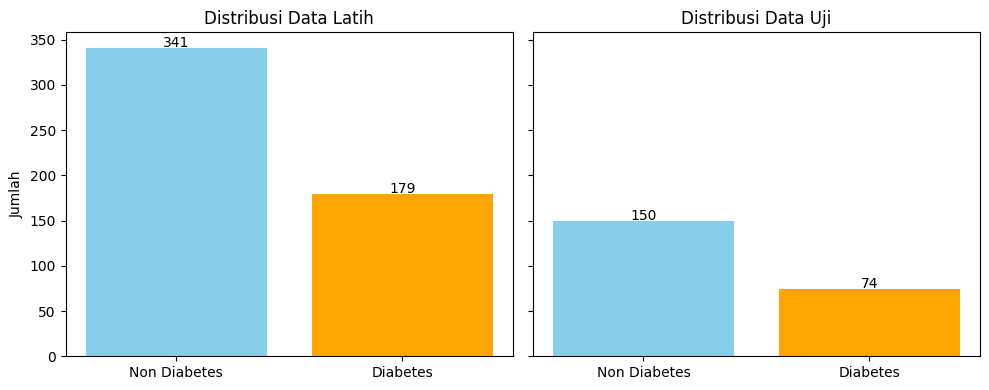

In [9]:
# distribusi kelas pada data latih dan data uji
train_y_counts = y_train.value_counts()
test_y_counts = y_test.value_counts()
test_counts  = y_test.value_counts().reindex([0, 1], fill_value=0)

labels = ["Non Diabetes", "Diabetes"]
x = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(x, train_y_counts.values, color=["skyblue", "orange"])
axes[0].set_title("Distribusi Data Latih")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Jumlah")

axes[1].bar(x, test_counts.values, color=["skyblue", "orange"])
axes[1].set_title("Distribusi Data Uji")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

# angka di atas bar (opsional tapi masih sederhana)
for ax, counts in zip(axes, [train_y_counts, test_counts]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

In [10]:
# balancing dengan SMOTE
jumlah_per_kelas = y_train.value_counts()
jumlah_kelas_mayoritas = jumlah_per_kelas.max()
jumlah_kelas_minoritas = jumlah_per_kelas.min()
IR = jumlah_kelas_mayoritas / jumlah_kelas_minoritas
print(f"Imbalance Ratio: {IR}")

if IR > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    y_train_smote = pd.Series(y_train_smote).reset_index(drop=True)
    X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
else:
    print("Data sudah cukup seimbang")

Imbalance Ratio: 1.905027932960894


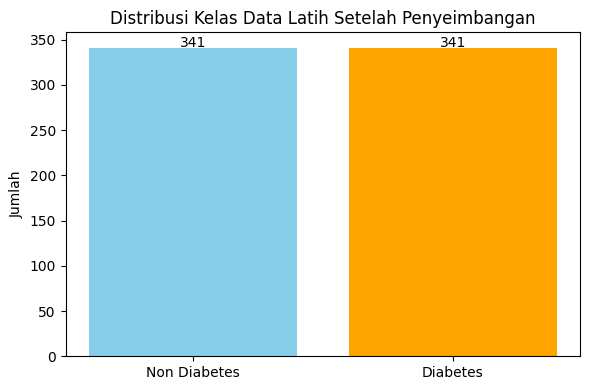

In [11]:
counts_smote =y_train_smote.value_counts()

plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote.values, color=["skyblue", "orange"])
plt.xticks([0, 1], ["Non Diabetes", "Diabetes"])
plt.ylabel("Jumlah")
plt.title("Distribusi Kelas Data Latih Setelah Penyeimbangan")

for i, v in enumerate(counts_smote.values):
    plt.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

In [12]:
# Cross-validation dengan KFold
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for split, (train_index, validasi_index) in enumerate(kfold.split(X_train_smote, y_train_smote), 1):
    print(f"split {split}:\n")
    print(f"Jumlah data train: {len(train_index)}")
    print(f"Jumlah data validation: {len(validasi_index)}\n")
    print(f"Train index: {', '.join(map(str, train_index))}")
    print(f"Validation index:  {', '.join(map(str, validasi_index))}\n")

split 1:

Jumlah data train: 545
Jumlah data validation: 137

Train index: 0, 1, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 40, 42, 43, 45, 46, 47, 48, 50, 52, 53, 57, 58, 59, 61, 62, 64, 66, 67, 68, 71, 73, 74, 75, 79, 80, 83, 84, 85, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 106, 107, 111, 112, 113, 114, 115, 116, 117, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 134, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 149, 150, 151, 152, 153, 154, 156, 157, 159, 160, 161, 162, 163, 166, 167, 168, 169, 170, 171, 172, 173, 175, 177, 178, 179, 180, 183, 184, 185, 186, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 200, 201, 202, 203, 205, 206, 207, 208, 214, 216, 217, 218, 219, 221, 222, 224, 225, 226, 228, 229, 230, 231, 232, 233, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 248, 249, 251, 252, 253, 254, 255, 256, 257, 258, 260, 261, 262, 263, 266, 2

In [13]:
# membuat model KNN dengan GridSearchCV
param_grid_knn = {
    "n_neighbors": [5, 7, 9, 11, 13, 15, 17, 19],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_knn.best_params_}")
results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx = grid_knn.best_index_
best_idx = grid_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn.best_score_:.4f}")
knn_final = grid_knn.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Best Score: 0.8181
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Fold 1: 0.8686
Fold 2: 0.8248
Fold 3: 0.8235
Fold 4: 0.8088
Fold 5: 0.7647
Mean: 0.8181


In [14]:
print(f"Metrik Jarak: {knn_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 682


In [15]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Hitung jarak dan probabilitas untuk seluruh data testing
distances_all, indices_all = knn_final.kneighbors(X_test)
prob_all = knn_final.predict_proba(X_test)[:, 1]

# 2. Filter data secara ketat
valid_indices = []
for i in range(len(distances_all)):
    dists = distances_all[i]
    prob = prob_all[i]

    # Syarat 1: Probabilitas BUKAN 0.0 dan BUKAN 1.0 (Harus ada campuran kelas tetangga)
    if prob == 0.0 or prob == 1.0:
        continue

    # Syarat 2: Jarak pertama tidak boleh 0.0000
    if dists[0] == 0:
        continue

    # Syarat 3: Jarak harus bervariasi (minimal 4 jarak berbeda dari 5 tetangga)
    unique_dists = np.unique(dists)
    if len(unique_dists) >= 4:
        valid_indices.append(i)

valid_indices = np.array(valid_indices)

# 3. Ambil 5 sampel acak dari daftar yang sudah difilter
if len(valid_indices) < 5:
    print(f"Catatan: Hanya ditemukan {len(valid_indices)} data yang memenuhi syarat ketat ini.")
    sample_idx = valid_indices
else:
    np.random.seed(42) # Angka seed agar hasilnya tetap sama jika di-run ulang
    sample_idx = np.random.choice(valid_indices, 5, replace=False)

# 4. Ambil data sampel berdasarkan indeks yang terpilih
X_sample = X_test.values[sample_idx] if hasattr(X_test, 'values') else X_test[sample_idx]
y_sample_asli = y_test.values[sample_idx] if hasattr(y_test, 'values') else y_test[sample_idx]
index_sample = y_test.index[sample_idx] if hasattr(y_test, 'index') else sample_idx

# 5. Dapatkan jarak dan indeks 5 tetangga terdekat khusus
distances = distances_all[sample_idx]
indices = indices_all[sample_idx]

# 6. Dapatkan probabilitas (Kelas 0 dan 1) dan prediksi akhir
prob_library = knn_final.predict_proba(X_sample)
pred_library = knn_final.predict(X_sample)

# 7. Ambil label asli dari data training untuk mengetahui kelas tetangga
y_train_array = y_train_smote.values if hasattr(y_train_smote, 'values') else y_train_smote

# 8. Susun data menjadi DataFrame
data_tabel = []
for i in range(len(X_sample)):
    row_data = {
        # 'Urutan di Data Uji': sample_idx[i],
        # 'Index': index_sample[i]
    }

    # Memasukkan jarak dan kelas untuk masing-masing ke-5 tetangga
    for k in range(5):
        dist = distances[i][k]
        kelas_tetangga = y_train_array[indices[i][k]]
        row_data[f'Tetangga {k+1}'] = f"{dist:.4f} (K:{kelas_tetangga})"

    # Memasukkan hasil probabilitas Kelas 0, Kelas 1, dan Prediksi
    # row_data['Probabilitas Kelas 0'] = round(prob_library[i][0], 5)
    # row_data['Probabilitas Kelas 1'] = round(prob_library[i][1], 5)
    row_data['Prediksi Model'] = pred_library[i]
    row_data['Label Asli'] = y_sample_asli[i]

    data_tabel.append(row_data)

df_knn_sempurna = pd.DataFrame(data_tabel)

print("--- DETAIL JARAK TETANGGA (VARIAN JARAK & PROBABILITAS CAMPURAN) ---")
display(df_knn_sempurna)

--- DETAIL JARAK TETANGGA (VARIAN JARAK & PROBABILITAS CAMPURAN) ---


,Tetangga 1,Tetangga 2,Tetangga 3,Tetangga 4,Tetangga 5,Prediksi Model,Label Asli
0,0.2490 (K:0),0.4080 (K:0),0.4172 (K:0),0.4274 (K:0),0.4329 (K:1),0,1
1,0.3191 (K:1),0.4675 (K:1),0.4858 (K:1),0.5012 (K:0),0.5235 (K:1),1,0
2,0.2843 (K:1),0.2895 (K:0),0.2936 (K:1),0.3047 (K:1),0.3062 (K:1),1,0
3,0.5389 (K:1),0.6452 (K:0),0.6942 (K:0),0.6989 (K:0),0.7209 (K:0),0,0
4,0.5700 (K:0),0.5844 (K:1),0.5991 (K:1),0.6134 (K:1),0.6286 (K:1),1,1


In [16]:
out_dir = Path("for_deployment")
joblib.dump(knn_final, out_dir / "knn_model.joblib")
knn_info = {
    "model": "KNN",
    "cv": {
        "n_folds": 5,
        "n_candidates": 48,
        "total_fits": 240,
    },
    "best_score": 0.9480,
    "best_params": {"metric": "manhattan", "n_neighbors": 9, "weights": "distance"},
    "fold_scores": [0.9426, 0.9342, 0.9616, 0.9370, 0.9644],
    "mean": 0.9480,
}
with open(out_dir / "knn_info.json", "w", encoding="utf-8") as f:
    json.dump(knn_info, f, indent=2, ensure_ascii=False)

In [17]:
# membuat model Logistic Regression dengan GridSearchCV
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_lr.fit(X_train_smote, y_train_smote)

print(f"LR Best Score: {grid_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_lr.best_params_}")

results_lr = pd.DataFrame(grid_lr.cv_results_)
best_idx = grid_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_lr.best_score_:.4f}")

lr_final = grid_lr.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7697
LR Best Params: {'C': np.float64(0.08858667904100823), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7883
Fold 2: 0.8029
Fold 3: 0.7426
Fold 4: 0.7500
Fold 5: 0.7647
Mean: 0.7697


In [18]:
print(f"Koefisien (Bobot): \n{lr_final.coef_}")
print(f"Intercept (Bias): {lr_final.intercept_}")
print(f"Jumlah Iterasi: {lr_final.n_iter_}")

Koefisien (Bobot): 
[[ 0.41228386  1.41036942 -0.04842795  0.30118245  0.57135991  0.43021453
   0.1910146   0.65598158]]
Intercept (Bias): [-1.19773038]
Jumlah Iterasi: [3]


In [19]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Pastikan data testing berbentuk matriks angka
X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# 2. Ambil koefisien (w) dan intercept (b)
w = lr_final.coef_[0]
b = lr_final.intercept_[0]

# 3. KALKULASI MATEMATIS MANUAL
# Hitung kombinasi linear (z) = w*x + b
z_manual = np.dot(X_test_array, w) + b

# Hitung f(x) menggunakan rumus Sigmoid
fx_manual = 1 / (1 + np.exp(-z_manual))

# Probabilitas Kelas 1 dan Kelas 0
p_manual_1 = fx_manual
p_manual_0 = 1 - p_manual_1

# 4. KEPUTUSAN PREDIKSI (Berdasarkan teori ambang batas > 0.5)
# Jika fx_manual >= 0.5, maka hasilnya 1. Jika tidak, hasilnya 0.
prediksi_manual = (fx_manual >= 0.5).astype(int)

# 5. SUSUN TABEL MANUAL
df_manual = pd.DataFrame({
    'Index Asli': y_test.index if hasattr(y_test, 'index') else range(len(y_test)),
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
    'Hasil z': z_manual.round(5),
    'Hasil f(x)': fx_manual.round(5),
    # 'Probabilitas Kelas 1': p_manual_1.round(5),
    # 'Probabilitas Kelas 0': p_manual_0.round(5),
    'Prediksi Model': prediksi_manual
})

print("--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---")
display(df_manual.head(5))

--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---


,Index Asli,Label Asli,Hasil z,Hasil f(x),Prediksi Model
0,609,1,0.46024,0.61307,1
1,539,0,-0.32092,0.42045,0
2,694,0,-0.01147,0.49713,0
3,350,0,-0.29668,0.42637,0
4,174,0,-0.57082,0.36105,0


In [20]:
# 1. TARIK DATA DARI LIBRARY
p_library = lr_final.predict_proba(X_test)
pred_library = lr_final.predict(X_test)

# 2. SUSUN TABEL LIBRARY
df_library = pd.DataFrame({
    'Index Asli': y_test.index if hasattr(y_test, 'index') else range(len(y_test)),
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
    'Probabilitas Kelas 1': p_library[:, 1].round(5),
    'Probabilitas Kelas 0': p_library[:, 0].round(5),
    'Prediksi Model': pred_library
})

print("--- HASIL KELUARAN PUSTAKA (SCIKIT-LEARN) ---")
display(df_library.head(5))

--- HASIL KELUARAN PUSTAKA (SCIKIT-LEARN) ---


,Index Asli,Label Asli,Probabilitas Kelas 1,Probabilitas Kelas 0,Prediksi Model
0,609,1,0.61307,0.38693,1
1,539,0,0.42045,0.57955,0
2,694,0,0.49713,0.50287,0
3,350,0,0.42637,0.57363,0
4,174,0,0.36105,0.63895,0


In [21]:
out_dir = Path("for_deployment")
# 1) simpan modelnya (wajib joblib/pickle)
joblib.dump(lr_final, out_dir / "lr_model.joblib")

# 2) simpan info hasilnya (boleh JSON)
lr_info = {
    "model": "LogisticRegression",
    "cv": {
        "n_folds": 5,
        "n_candidates": 80,
        "total_fits": 400,
    },
    "best_score": 0.7574,
    "best_params": {
        "C": 0.03359818286283781,   # pastikan float biasa (bukan np.float64) biar aman di JSON
        "penalty": "l2",
        "solver": "liblinear",
    },
    "fold_scores": [0.7104, 0.7671, 0.7370, 0.8329, 0.7397],
    "mean": 0.7574,

    # tambahan yang kamu minta
    "coef": [
        [0.57947611, 1.40163103, -0.0347297, 0.25106864, 0.27961099, 0.55780767, 0.22048715, 0.48571201]
    ],
    "intercept": [-1.17551152],
    "n_iter": [3],
}

with open(out_dir / "lr_info.json", "w", encoding="utf-8") as f:
    json.dump(lr_info, f, indent=2, ensure_ascii=False)

In [22]:
# membuat model SVM dengan GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}

grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm.fit(X_train_smote, y_train_smote)

print(f"SVM Best Score: {grid_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_svm.best_params_}")

results_svm = pd.DataFrame(grid_svm.cv_results_)
best_idx = grid_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm.best_score_:.4f}")

svm_final = grid_svm.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.7859
SVM Best Params: {'C': 1000, 'gamma': 'auto', 'kernel': 'rbf'}
Fold 1: 0.7883
Fold 2: 0.8029
Fold 3: 0.7574
Fold 4: 0.8088
Fold 5: 0.7721
Mean: 0.7859


In [23]:
print(f"Indeks Support Vectors: {svm_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_final.n_support_[0]} (kelas 0), {svm_final.n_support_[1]} (kelas 1)")
# print(f"Bobot Fitur (coef_): \n{svm_final.coef_}")
print(f"Konstanta Bias (intercept_): {svm_final.intercept_}")
print(f"Total Support Vectors: {sum(svm_final.n_support_)}")

Indeks Support Vectors: [  2   3   5   6   7   9  18  19  24  25  27  28  34  38  39  40  41  42
  44  49  52  56  60  62  65  67  74  76  77  79  93 100 104 106 107 109
 111 113 115 118 121 123 129 131 133 143 149 151 152 154 159 161 163 170
 171 172 175 184 185 186 188 189 192 193 197 199 202 204 205 208 211 212
 219 225 226 230 231 233 234 239 241 245 252 253 254 256 258 260 261 265
 267 270 271 275 287 295 303 305 308 309 311 312 313 316 318 319 328 330
 332 340 345 346 348 352 353 354 356 358 359 360 366 368 369 373 375 376
 379 380 383 386 390 392 397 398 400 413 419 420 422 425 428 430 432 437
 438 443 444 446 448 450 452 453 455 456 459 461 464 466 467 471 474 483
 484 486 490 491 493 495 498 499 508 511 515  23  26  36  43  45  53  57
  63  64  71  75  81  85  88  91  97 119 122 130 138 140 144 147 158 166
 168 169 178 187 190 191 201 203 210 213 214 215 218 235 237 244 248 259
 262 278 279 284 289 291 294 298 300 301 304 317 320 322 324 325 331 333
 334 335 337 338 339 341 34

In [24]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Pastikan data berformat array
X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# 2. Ekstrak parameter matematis dari model SVM RBF Anda
SVs = svm_final.support_vectors_       # Koordinat titik Support Vectors
dual_coefs = svm_final.dual_coef_[0]   # Koefisien dual (Alpha * y)
b = svm_final.intercept_[0]            # Nilai bias (konstanta)
gamma = svm_final._gamma               # Nilai gamma dari kernel RBF

# 3. KALKULASI MATEMATIS FUNGSI KEPUTUSAN UNTUK SELURUH DATA TESTING
fx_list = []
prediksi_list = []

for sample_x in X_test_array:
    # a. Hitung kuadrat jarak (Euclidean) ke semua Support Vectors
    sq_distances = np.sum((SVs - sample_x) ** 2, axis=1)

    # b. Fungsi Kernel RBF
    K = np.exp(-gamma * sq_distances)

    # c. Fungsi Keputusan f(x)
    fx = np.dot(dual_coefs, K) + b
    fx_list.append(fx)

    # d. Aturan Keputusan SVM (Threshold 0)
    prediksi = 1 if fx >= 0 else 0
    prediksi_list.append(prediksi)

# 4. SUSUN TABEL HASIL MATEMATIS
df_matematis = pd.DataFrame({
    'Index Asli': y_test.index if hasattr(y_test, 'index') else range(len(y_test)),
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
    'Nilai Jarak f(x)': np.round(fx_list, 5),
    'Prediksi Model': prediksi_list
})

print("--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN SVM ---")
display(df_matematis.head(15))

--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN SVM ---


,Index Asli,Label Asli,Nilai Jarak f(x),Prediksi Model
0,609,1,1.35952,1
1,539,0,-1.19067,0
2,694,0,-0.42021,0
3,350,0,-0.87330,0
4,174,0,-2.28926,0
5,81,0,-3.78135,0
6,355,1,1.32269,1
7,424,1,2.21245,1
8,523,0,-0.80009,0
9,617,0,-2.62343,0


In [25]:
# 1. TARIK DATA DARI LIBRARY SCIKIT-LEARN
fx_library = svm_final.decision_function(X_test)
prob_library = svm_final.predict_proba(X_test)
pred_library = svm_final.predict(X_test)

# 2. SUSUN TABEL LIBRARY
df_library = pd.DataFrame({
    'Index Asli': y_test.index if hasattr(y_test, 'index') else range(len(y_test)),
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
    'Nilai Jarak f(x) (Library)': np.round(fx_library, 5),
    'Probabilitas Kelas 0': np.round(prob_library[:, 0], 5),
    'Probabilitas Kelas 1': np.round(prob_library[:, 1], 5),
    'Prediksi Model (Library)': pred_library
})

print("--- HASIL KELUARAN PUSTAKA SCIKIT-LEARN ---")
display(df_library.head(15))

--- HASIL KELUARAN PUSTAKA SCIKIT-LEARN ---


,Index Asli,Label Asli,Nilai Jarak f(x) (Library),Probabilitas Kelas 0,Probabilitas Kelas 1,Prediksi Model (Library)
0,609,1,1.35952,0.18641,0.81359,1
1,539,0,-1.19067,0.81021,0.18979,0
2,694,0,-0.42021,0.63649,0.36351,0
3,350,0,-0.87330,0.74790,0.25210,0
4,174,0,-2.28926,0.93769,0.06231,0
5,81,0,-3.78135,0.98800,0.01200,0
6,355,1,1.32269,0.19291,0.80709,1
7,424,1,2.21245,0.07921,0.92079,1
8,523,0,-0.80009,0.73174,0.26826,0
9,617,0,-2.62343,0.95512,0.04488,0


In [26]:
import numpy as np

# 1. Ambil salah satu nilai f(x) dari data testing (misal indeks ke-0)
test_fx = svm_final.decision_function(X_test)[0]

# 2. Ambil parameter Platt Scaling
A_param = svm_final.probA_[0]
B_param = svm_final.probB_[0]

# 3. Hitung Manual menggunakan rumus Platt Scaling (Sigmoid)
# Rumus: 1 / (1 + exp(A * f(x) + B))
p_manual_1 = 1 / (1 + np.exp(A_param * test_fx + B_param))
p_manual_0 = 1 - p_manual_1

# 4. Bandingkan dengan hasil Library
p_library = svm_final.predict_proba(X_test)[0]
print(f"Nilai A (probA_): {A_param:.5f}")
print(f"Nilai B (probB_): {B_param:.5f}")

print(f"Jarak f(x) Data ke-0    : {test_fx:.5f}")
print(f"--- Hasil Manual Platt Scaling ---")
print(f"Probabilitas Kelas 1    : {p_manual_1:.5f}")
print(f"Probabilitas Kelas 0    : {p_manual_0:.5f}")
print(f"\n--- Hasil Library predict_proba ---")
print(f"Probabilitas (0, 1)     : {p_library.round(5)}")

Nilai A (probA_): -1.14682
Nilai B (probB_): -0.08592
Jarak f(x) Data ke-0    : 1.35952
--- Hasil Manual Platt Scaling ---
Probabilitas Kelas 1    : 0.83822
Probabilitas Kelas 0    : 0.16178

--- Hasil Library predict_proba ---
Probabilitas (0, 1)     : [0.18641 0.81359]


In [27]:
# 1. TARIK DATA DARI LIBRARY SCIKIT-LEARN
fx_library = svm_final.decision_function(X_test)
prob_library = svm_final.predict_proba(X_test)
pred_library = svm_final.predict(X_test)

# 2. SUSUN TABEL LIBRARY
df_library = pd.DataFrame({
    'Index Asli': y_test.index if hasattr(y_test, 'index') else range(len(y_test)),
    'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
    'Nilai Jarak f(x) (Library)': np.round(fx_library, 5),
    'Probabilitas Kelas 0': np.round(prob_library[:, 0], 5),
    'Probabilitas Kelas 1': np.round(prob_library[:, 1], 5),
    'Prediksi Model (Library)': pred_library
})

print("--- HASIL KELUARAN PUSTAKA SCIKIT-LEARN ---")
display(df_library.head(15))

--- HASIL KELUARAN PUSTAKA SCIKIT-LEARN ---


,Index Asli,Label Asli,Nilai Jarak f(x) (Library),Probabilitas Kelas 0,Probabilitas Kelas 1,Prediksi Model (Library)
0,609,1,1.35952,0.18641,0.81359,1
1,539,0,-1.19067,0.81021,0.18979,0
2,694,0,-0.42021,0.63649,0.36351,0
3,350,0,-0.87330,0.74790,0.25210,0
4,174,0,-2.28926,0.93769,0.06231,0
5,81,0,-3.78135,0.98800,0.01200,0
6,355,1,1.32269,0.19291,0.80709,1
7,424,1,2.21245,0.07921,0.92079,1
8,523,0,-0.80009,0.73174,0.26826,0
9,617,0,-2.62343,0.95512,0.04488,0


In [28]:
out_dir = Path("for_deployment")

# simpan model
joblib.dump(svm_final, out_dir / "svm_model.joblib")

# simpan info (hardcode)
svm_info = {
    "model": "SVM",
    "cv": {
        "n_folds": 5,
        "n_candidates": 20,
        "total_fits": 100,
    },
    "best_score": 0.9190,
    "best_params": {
        "C": 1000,
        "gamma": "scale",
        "kernel": "rbf",
    },
    "fold_scores": [0.9044, 0.9397, 0.9068, 0.9151, 0.9288],
    "mean": 0.9190,
}

with open(out_dir / "svm_info.json", "w", encoding="utf-8") as f:
    json.dump(svm_info, f, indent=2, ensure_ascii=False)


In [29]:
# membuat model ann dengan GridSearchCV
param_grid_ann = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
}

grid_ann = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann.fit(X_train_smote, y_train_smote)

print(f"ANN Best Score: {grid_ann.best_score_:.4f}")
print(f"ANN Best Params: {grid_ann.best_params_}")

results_ann = pd.DataFrame(grid_ann.cv_results_)
best_idx = grid_ann.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann.best_score_:.4f}")

ann_final = grid_ann.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
ANN Best Score: 0.7991
ANN Best Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'max_iter': 1000}
Fold 1: 0.8102
Fold 2: 0.8102
Fold 3: 0.7647
Fold 4: 0.8162
Fold 5: 0.7941
Mean: 0.7991


In [30]:
# Hasil pelatihan ANN
print(ann_final.loss_)
print(ann_final.n_iter_)
print(ann_final.t_)
print(ann_final.n_layers_)
print(ann_final.n_outputs_)
print(ann_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_final.intercepts_]}")

0.4021716369777795
879
599478
3
1
logistic

Shape Matriks Bobot (coefs_): [(8, 100), (100, 1)]
Shape Vektor Bias (intercepts_): [(100,), (1,)]


In [31]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data berformat array
# X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# # 2. Ekstrak matriks bobot (W) dan bias (b) dari model ANN
# W1, W2, W3 = ann_final.coefs_
# b1, b2, b3 = ann_final.intercepts_

# # 3. PROSES FORWARD PROPAGATION MANUAL
# # --- Langkah 1: Input ke Hidden Layer 1 ---
# # Z1 = (X * W1) + b1
# Z1 = np.dot(X_test_array, W1) + b1
# # Fungsi Aktivasi ReLU: max(0, Z)
# A1 = np.maximum(0, Z1)

# # --- Langkah 2: Hidden Layer 1 ke Hidden Layer 2 ---
# # Z2 = (A1 * W2) + b2
# Z2 = np.dot(A1, W2) + b2
# # Fungsi Aktivasi ReLU
# A2 = np.maximum(0, Z2)

# # --- Langkah 3: Hidden Layer 2 ke Output Layer ---
# # Z3 = (A2 * W3) + b3
# Z3 = np.dot(A2, W3) + b3
# # Karena matriks hasil ukurannya (N, 1), kita ratakan (flatten) jadi 1 dimensi
# Z3 = Z3.flatten()

# # Fungsi Aktivasi Output: Logistic (Sigmoid)
# p_manual_1 = 1 / (1 + np.exp(-Z3))
# p_manual_0 = 1 - p_manual_1

# # 4. HASIL KELUARAN LIBRARY SCIKIT-LEARN UNTUK DIBANDINGKAN
# p_library_1 = ann_final.predict_proba(X_test)[:, 1]

# # 5. SUSUN TABEL KOMPARASI
# df_ann_komparasi = pd.DataFrame({
#     'Index Asli': y_test.index if hasattr(y_test, 'index') else range(len(y_test)),
#     'Probabilitas Kelas 1 (Manual Forward Prop)': p_manual_1.round(6),
#     'Probabilitas Kelas 1 (Library)': p_library_1.round(6),
# })

# # Cek kesesuaian (pembulatan 5 desimal untuk menoleransi perbedaan komputasi presisi float)
# df_ann_komparasi['Apakah Sama?'] = (df_ann_komparasi['Probabilitas Kelas 1 (Manual Forward Prop)'].round(5) == df_ann_komparasi['Probabilitas Kelas 1 (Library)'].round(5))
# df_ann_komparasi['Apakah Sama?'] = df_ann_komparasi['Apakah Sama?'].replace({True: '✅ Ya', False: '❌ Tidak'})

# display(df_ann_komparasi.head(15))

In [32]:
out_dir = Path("for_deployment")

# simpan model
joblib.dump(ann_final, out_dir / "ann_model.joblib")

# simpan info (hardcode)
ann_info = {
    "model": "ANN",
    "cv": {
        "n_folds": 5,
        "n_candidates": 144,
        "total_fits": 720,
    },
    "best_score": 0.8412,
    "best_params": {
        "activation": "relu",
        "alpha": 0.0001,
        "hidden_layer_sizes": [50, 50],  # JSON tidak punya tuple, jadi pakai list
        "max_iter": 1000,
    },
    "fold_scores": [0.8005, 0.8685, 0.8521, 0.8575, 0.8274],
    "mean": 0.8412,
}

with open(out_dir / "ann_info.json", "w", encoding="utf-8") as f:
    json.dump(ann_info, f, indent=2, ensure_ascii=False)

In [33]:
kfold_meta = KFold(n_splits=5, shuffle=True, random_state=42)

In [34]:
# membuat fitur training meta learner dengan prediksi probabilitas
prediksi_lr = cross_val_predict(lr_final, X_train_smote, y_train_smote, cv=kfold_meta, method="predict_proba")
prediksi_knn = cross_val_predict(knn_final, X_train_smote, y_train_smote, cv=kfold_meta, method="predict_proba")
prediksi_svm = cross_val_predict(svm_final, X_train_smote, y_train_smote, cv=kfold_meta, method="predict_proba")
prediksi_ann = cross_val_predict(ann_final, X_train_smote, y_train_smote, cv=kfold_meta, method="predict_proba")

In [35]:
fitur_meta = np.column_stack([
    prediksi_lr,
    prediksi_knn,
    prediksi_svm,
    prediksi_ann,
    # y_train_smote
])
df_fitur_meta = pd.DataFrame(
    fitur_meta,
    columns=[
        "lr_prob_0", "lr_prob_1",
        "knn_prob_0", "knn_prob_1",
        "svm_prob_0", "svm_prob_1",
        "ann_prob_0", "ann_prob_1",
        # "Outcome"
    ],
)
# df_fitur_meta["Outcome"] = df_fitur_meta["Outcome"].astype(int)

In [36]:
df_fitur_meta

,lr_prob_0,lr_prob_1,knn_prob_0,knn_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.612407,0.387593,1.000000,0.000000,0.957016,0.042984,0.980539,0.019461
1,0.572953,0.427047,1.000000,0.000000,0.895417,0.104583,0.947847,0.052153
2,0.540216,0.459784,0.737057,0.262943,0.706671,0.293329,0.834449,0.165551
3,0.544111,0.455889,1.000000,0.000000,0.779938,0.220062,0.777870,0.222130
4,0.445612,0.554388,0.241126,0.758874,0.284852,0.715148,0.295455,0.704545
...,...,...,...,...,...,...,...,...
677,0.459568,0.540432,0.353106,0.646894,0.124720,0.875280,0.191963,0.808037
678,0.452934,0.547066,0.071118,0.928882,0.300331,0.699669,0.396938,0.603062
679,0.522169,0.477831,0.094385,0.905615,0.538079,0.461921,0.390159,0.609841
680,0.477258,0.522742,0.121879,0.878121,0.305606,0.694394,0.262830,0.737170


In [37]:
# simpan ke excel
df_fitur_meta.to_excel("fitur_meta_training.xlsx", index=False)

In [38]:
# membuat fitur testing meta learner dengan prediksi probabilitas
prediksi_uji_lr = lr_final.predict_proba(X_test)
prediksi_uji_knn = knn_final.predict_proba(X_test)
prediksi_uji_svm = svm_final.predict_proba(X_test)
prediksi_uji_ann = ann_final.predict_proba(X_test)
fitur_meta_uji = np.column_stack([prediksi_uji_lr, prediksi_uji_knn, prediksi_uji_svm, prediksi_uji_ann])
df_fitur_meta_uji = pd.DataFrame(
    fitur_meta_uji,
    columns=df_fitur_meta.columns,
)

In [39]:
df_fitur_meta_uji

,lr_prob_0,lr_prob_1,knn_prob_0,knn_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.386928,0.613072,0.134350,0.865650,0.186406,0.813594,0.233139,0.766861
1,0.579549,0.420451,1.000000,0.000000,0.810215,0.189785,0.921186,0.078814
2,0.502868,0.497132,1.000000,0.000000,0.636491,0.363509,0.634714,0.365286
3,0.573630,0.426370,1.000000,0.000000,0.747899,0.252101,0.841424,0.158576
4,0.638953,0.361047,1.000000,0.000000,0.937689,0.062311,0.959058,0.040942
...,...,...,...,...,...,...,...,...
219,0.330741,0.669259,0.291236,0.708764,0.555000,0.445000,0.240062,0.759938
220,0.433378,0.566622,0.182998,0.817002,0.176157,0.823843,0.112878,0.887122
221,0.517581,0.482419,0.752068,0.247932,0.486698,0.513302,0.438708,0.561292
222,0.358563,0.641437,0.427976,0.572024,0.303419,0.696581,0.306391,0.693609


In [40]:
# simpan fitur meta testing
df_fitur_meta_uji.to_excel("fitur_meta_testing.xlsx", index=False)

In [41]:
X_meta_latih = df_fitur_meta
y_meta_latih = y_train_smote.reset_index(drop=True)

X_meta_uji = df_fitur_meta_uji
y_meta_uji = y_test

In [42]:
# membuat model KNN Meta dengan GridSearchCV
grid_knn_meta = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold_meta,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta.fit(X_meta_latih, y_meta_latih)

print(f"KNN Meta Best Score: {grid_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_knn_meta.best_params_}")

results_knn_meta = pd.DataFrame(grid_knn_meta.cv_results_)
best_idx = grid_knn_meta.best_index_
for fold in range(kfold_meta.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn_meta.best_score_:.4f}")

knn_meta_final = grid_knn_meta.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN Meta Best Score: 0.8107
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Fold 1: 0.8759
Fold 2: 0.8248
Fold 3: 0.7868
Fold 4: 0.8088
Fold 5: 0.7574
Mean: 0.8107


In [43]:
print(f"Metrik Jarak: {knn_meta_final.effective_metric_}")
print(f"Jumlah Sampel Latihan: {knn_meta_final.n_samples_fit_}")

Metrik Jarak: manhattan
Jumlah Sampel Latihan: 682


In [44]:
joblib.dump(knn_meta_final,    out_dir / "knn_meta_model.joblib")
knn_meta_info = {
    "model": "KNN_META",
    "cv": {"n_folds": 5, "n_candidates": 48, "total_fits": 240},
    "best_score": 0.9480,
    "best_params": {"metric": "manhattan", "n_neighbors": 13, "weights": "uniform"},
    "fold_scores": [0.9372, 0.9397, 0.9671, 0.9452, 0.9507],
    "mean": 0.9480,
}
with open(out_dir / "knn_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(knn_meta_info, f, indent=2, ensure_ascii=False)


In [45]:
# membuat model Logistic Regression Meta dengan GridSearchCV
grid_logreg_meta = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold_meta,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_logreg_meta.fit(X_meta_latih, y_meta_latih)

print(f"LogReg Meta Best Score: {grid_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_logreg_meta.best_params_}")

results_logreg_meta = pd.DataFrame(grid_logreg_meta.cv_results_)
best_idx = grid_logreg_meta.best_index_
for fold in range(kfold_meta.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_logreg_meta.best_score_:.4f}")

logreg_meta_final = grid_logreg_meta.best_estimator_


Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.8152
LogReg Meta Best Params: {'C': np.float64(0.615848211066026), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.8540
Fold 2: 0.8248
Fold 3: 0.8162
Fold 4: 0.7868
Fold 5: 0.7941
Mean: 0.8152


In [46]:
print(f"Koefisien (Bobot): \n{logreg_meta_final.coef_}")
print(f"Intercept (Bias): {logreg_meta_final.intercept_}")
print(f"Jumlah Iterasi: {logreg_meta_final.n_iter_}")

Koefisien (Bobot): 
[[-0.24479389  0.10304974 -2.0790221   1.93727796 -0.48321876  0.34147462
  -0.58688275  0.44513861]]
Intercept (Bias): [-0.14174414]
Jumlah Iterasi: [5]


In [47]:
joblib.dump(logreg_meta_final, out_dir / "logreg_meta_model.joblib")
logreg_meta_info = {
    "model": "LogReg_META",
    "cv": {"n_folds": 5, "n_candidates": 80, "total_fits": 400},
    "best_score": 0.9485,
    "best_params": {
        "C": 0.23357214690901212,  # float biasa biar aman di JSON
        "penalty": "l1",
        "solver": "liblinear",
    },
    "fold_scores": [0.9426, 0.9397, 0.9589, 0.9397, 0.9616],
    "mean": 0.9485,
}
with open(out_dir / "logreg_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(logreg_meta_info, f, indent=2, ensure_ascii=False)

In [48]:
# membuat model Support Vector Machine Meta dengan GridSearchCV
grid_svm_meta = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold_meta,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm_meta.fit(X_meta_latih, y_meta_latih)

print(f"SVM Meta Best Score: {grid_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_svm_meta.best_params_}")

results_svm_meta = pd.DataFrame(grid_svm_meta.cv_results_)
best_idx = grid_svm_meta.best_index_
for fold in range(kfold_meta.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm_meta.best_score_:.4f}")

svm_meta_final = grid_svm_meta.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score: 0.8181
SVM Meta Best Params: {'C': 1000, 'gamma': 'auto', 'kernel': 'rbf'}
Fold 1: 0.8832
Fold 2: 0.8248
Fold 3: 0.7941
Fold 4: 0.8162
Fold 5: 0.7721
Mean: 0.8181


In [49]:
print(f"Indeks Support Vectors: {svm_meta_final.support_}")
print(f"Jumlah Support Vectors per kelas: {svm_meta_final.n_support_}")
# print(f"Bobot Fitur (coef_): \n{svm_meta_final.coef_}")
print(f"Konstanta Bias (intercept_): {svm_meta_final.intercept_}")

Indeks Support Vectors: [  5   6   7   9  14  19  20  24  25  28  34  39  40  42  49  55  56  60
  62  65  67  68  74  76  77  79  93 100 103 104 106 107 109 111 115 116
 118 121 123 129 133 143 152 154 159 164 172 175 184 186 188 189 193 197
 205 208 211 212 219 225 229 230 231 233 239 241 245 249 252 256 260 261
 265 267 268 270 275 287 295 305 308 309 311 312 315 316 326 329 330 332
 340 345 353 356 358 359 360 366 368 373 376 379 380 383 386 390 392 394
 397 398 400 413 419 422 425 430 432 437 444 446 448 452 453 456 461 464
 466 471 474 483 484 490 495 498 499 508 515  22  23  31  32  33  36  37
  45  53  57  64  71  75  85  88  89  91  95  96  97 119 122 128 130 138
 140 147 153 166 169 178 190 191 206 213 215 218 237 242 248 259 262 263
 278 279 289 291 294 298 300 301 304 320 322 324 325 331 333 334 337 339
 341 351 372 377 382 385 395 401 405 427 434 440 442 447 457 460 469 475
 477 479 481 494 500 504 513 517 521 524 532 548 550 557 559 561 567 570
 571 572 576 578 579 584 58

In [50]:
joblib.dump(svm_meta_final,out_dir / "svm_meta_model.joblib")
svm_meta_info = {
    "model": "SVM_META",
    "cv": {"n_folds": 5, "n_candidates": 20, "total_fits": 100},
    "best_score": 0.9485,
    "best_params": {"C": 0.1, "gamma": "scale", "kernel": "rbf"},
    "fold_scores": [0.9454, 0.9370, 0.9589, 0.9452, 0.9562],
    "mean": 0.9485,
}
with open(out_dir / "svm_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(svm_meta_info, f, indent=2, ensure_ascii=False)


In [51]:
# membuat model ANN Meta dengan GridSearchCV
grid_ann_meta = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold_meta,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann_meta.fit(X_meta_latih, y_meta_latih)

print(f"ANN Meta Best Score: {grid_ann_meta.best_score_:.4f}")
print(f"ANN Meta Best Params: {grid_ann_meta.best_params_}")

results_ann_meta = pd.DataFrame(grid_ann_meta.cv_results_)
best_idx = grid_ann_meta.best_index_
for fold in range(kfold_meta.get_n_splits()):
    fold_score = results_ann_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann_meta.best_score_:.4f}")

ann_meta_final = grid_ann_meta.best_estimator_


Fitting 5 folds for each of 144 candidates, totalling 720 fits
ANN Meta Best Score: 0.8181
ANN Meta Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'max_iter': 500}
Fold 1: 0.8832
Fold 2: 0.8321
Fold 3: 0.8015
Fold 4: 0.8162
Fold 5: 0.7574
Mean: 0.8181


In [52]:
# Hasil pelatihan ANN
print(ann_meta_final.loss_)
print(ann_meta_final.n_iter_)
print(ann_meta_final.t_)
print(ann_meta_final.n_layers_)
print(ann_meta_final.n_outputs_)
print(ann_meta_final.out_activation_)
print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_meta_final.coefs_]}")
print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_meta_final.intercepts_]}")

0.3804823709192544
247
168454
4
1
logistic

Shape Matriks Bobot (coefs_): [(8, 50), (50, 50), (50, 1)]
Shape Vektor Bias (intercepts_): [(50,), (50,), (1,)]


In [53]:
joblib.dump(ann_meta_final,    out_dir / "ann_meta_model.joblib")
ann_meta_info = {
    "model": "ANN_META",
    "cv": {"n_folds": 5, "n_candidates": 144, "total_fits": 720},
    "best_score": 0.9491,
    "best_params": {
        "activation": "logistic",
        "alpha": 0.0001,
        "hidden_layer_sizes": [50, 50],  # JSON tidak punya tuple → pakai list
        "max_iter": 100,
    },
    "fold_scores": [0.9454, 0.9370, 0.9616, 0.9452, 0.9562],
    "mean": 0.9491,
}
with open(out_dir / "ann_meta_info.json", "w", encoding="utf-8") as f:
    json.dump(ann_meta_info, f, indent=2, ensure_ascii=False)

In [54]:
# contoh prediksi dengan model ANN Meta terbaik
best_meta_ann = grid_ann_meta.best_estimator_
best_meta_ann.predict(X_meta_uji)

array([1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1])

In [55]:
# pengujian model meta learner terbaik dengan data uji
pred_model_dasar = {
    "LogReg": lr_final.predict(X_test),
    "KNN": knn_final.predict(X_test),
    "SVM": svm_final.predict(X_test),
    "ANN": ann_final.predict(X_test),
}

stacking_predictions = {
    "Stacking_KNN": knn_meta_final.predict(X_meta_uji),
    "Stacking_SVM": svm_meta_final.predict(X_meta_uji),
    "Stacking_ANN": ann_meta_final.predict(X_meta_uji),
    "Stacking_LogReg": logreg_meta_final.predict(X_meta_uji),
}


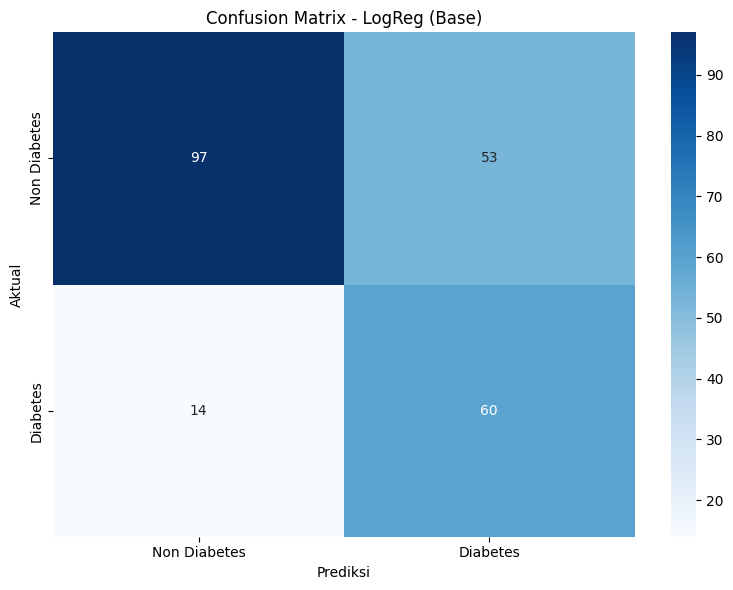

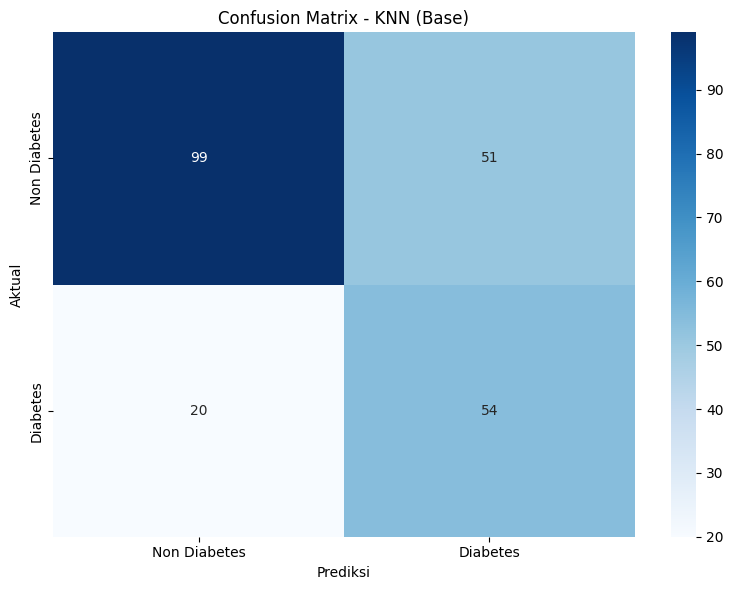

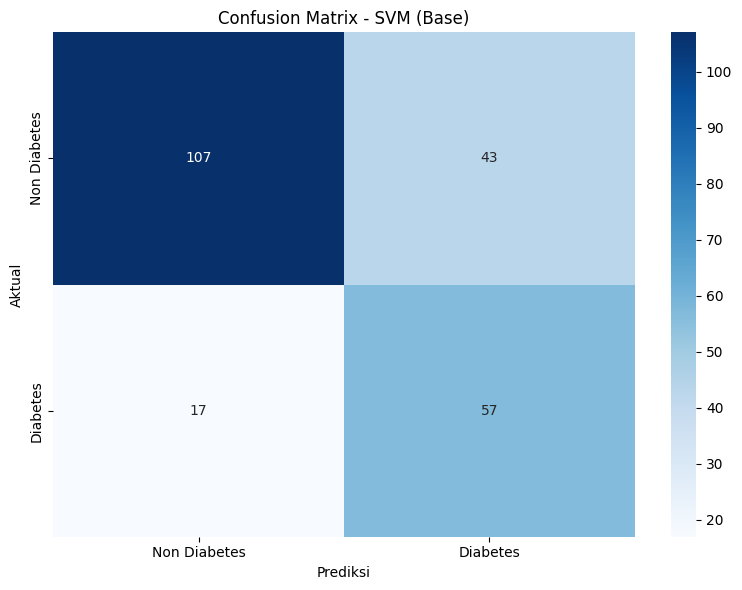

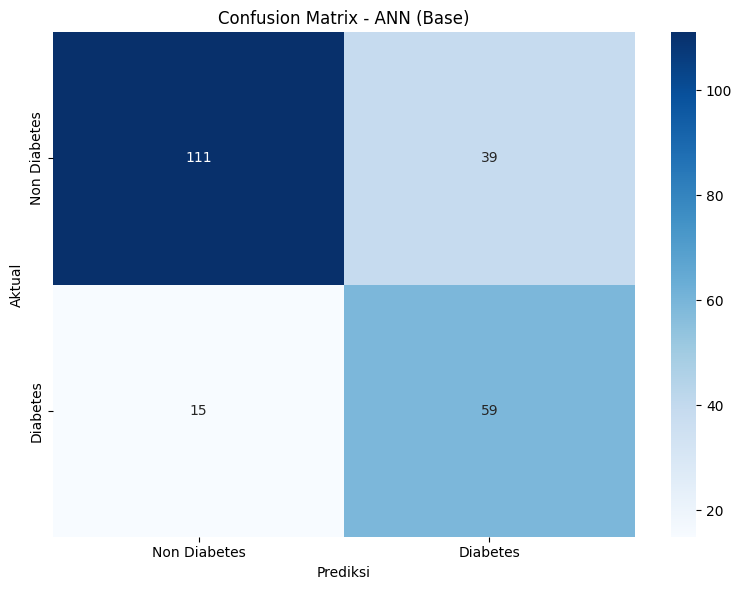

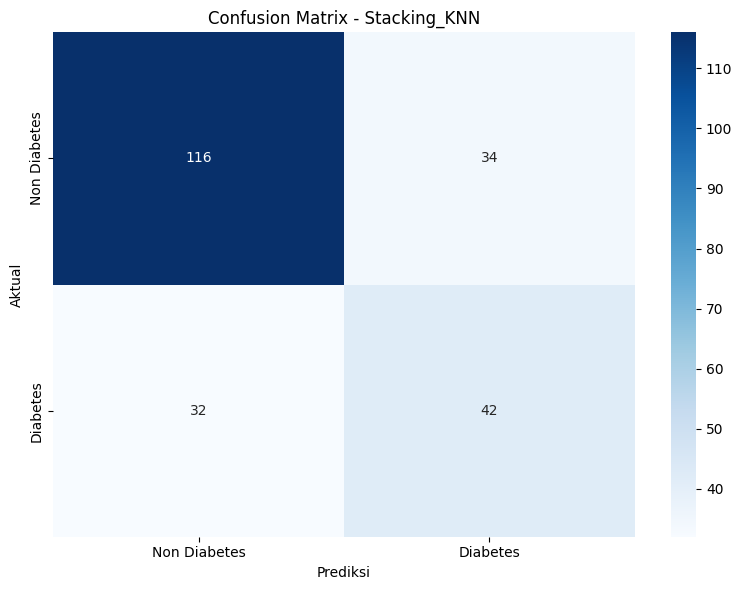

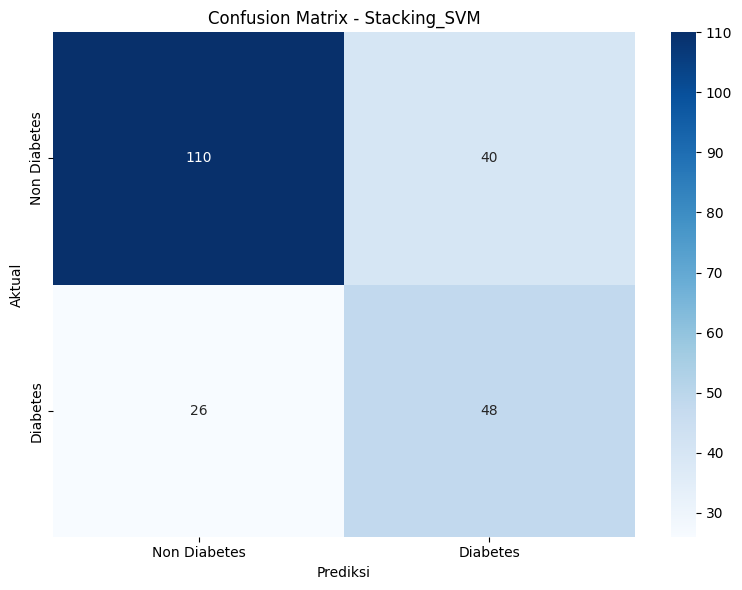

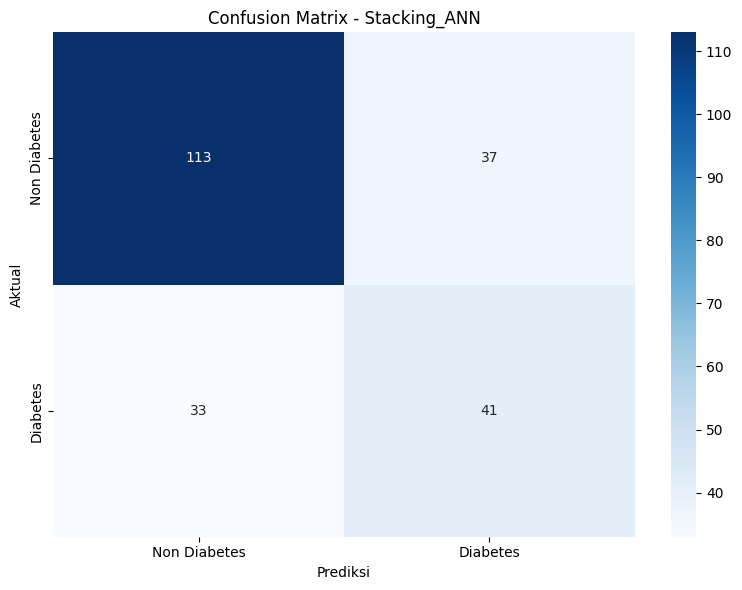

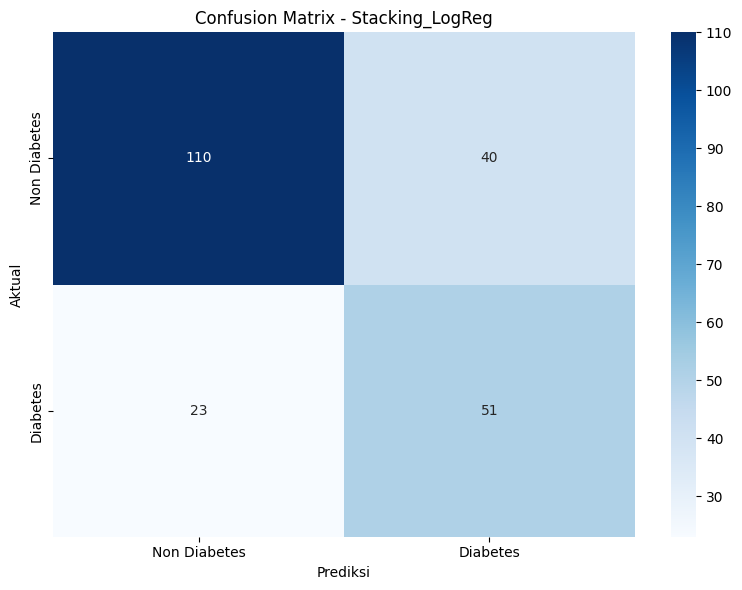

In [56]:
# evaluasi model
# ================================
# 4.2.14 Confusion Matrix
# ================================
def plot_confusion_matrix(y_asli, y_prediksi, nama_model):
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_asli, y_prediksi)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Non Diabetes", "Diabetes"],
        yticklabels=["Non Diabetes", "Diabetes"],
    )
    ax.set_title(f"Confusion Matrix - {nama_model}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

for nama_model, prediksi in pred_model_dasar.items():
    plot_confusion_matrix(y_test, prediksi, f"{nama_model} (Base)")

for nama_model, prediksi in stacking_predictions.items():
    plot_confusion_matrix(y_test, prediksi, nama_model)

In [57]:
def hitung_metrik(y_asli, y_prediksi, nama_model):
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi)
    recall = recall_score(y_asli, y_prediksi)
    f1 = f1_score(y_asli, y_prediksi)
    return {
        "Model": nama_model,
        "Akurasi": round(akurasi, 4),
        "Presisi": round(presisi, 4),
        "Recall": round(recall, 4),
        "Skor-F1": round(f1, 4),
    }

hasil_perbandingan = []
for nama_model, prediksi in pred_model_dasar.items():
    hasil_perbandingan.append(hitung_metrik(y_test, prediksi, nama_model))
for nama_model, prediksi in stacking_predictions.items():
    hasil_perbandingan.append(hitung_metrik(y_test, prediksi, nama_model))

df_perbandingan = pd.DataFrame(hasil_perbandingan)
print(df_perbandingan)

             Model  Akurasi  Presisi  Recall  Skor-F1
0           LogReg   0.7009   0.5310  0.8108   0.6417
1              KNN   0.6830   0.5143  0.7297   0.6034
2              SVM   0.7321   0.5700  0.7703   0.6552
3              ANN   0.7589   0.6020  0.7973   0.6860
4     Stacking_KNN   0.7054   0.5526  0.5676   0.5600
5     Stacking_SVM   0.7054   0.5455  0.6486   0.5926
6     Stacking_ANN   0.6875   0.5256  0.5541   0.5395
7  Stacking_LogReg   0.7188   0.5604  0.6892   0.6182


In [58]:
import pandas as pd

def cv_results_to_export(nama_model, results_df):
    df = results_df[["params", "mean_test_score", "rank_test_score"]].copy()
    df = df.dropna(subset=["mean_test_score"])

    df.rename(columns={
        "params": "Kombinasi Parameter",
        "mean_test_score": "Rata Rata",
        "rank_test_score": "Peringkat",
    }, inplace=True)

    df.insert(0, "Nama Model", nama_model)
    df["Kombinasi Parameter"] = df["Kombinasi Parameter"].astype(str)
    return df

# =========================
# BASE (sheet 1)
# =========================
df_base = pd.concat([
    cv_results_to_export("KNN", results_knn),
    cv_results_to_export("LogReg", results_lr),
    cv_results_to_export("SVM", results_svm),
    cv_results_to_export("ANN", results_ann),
], ignore_index=True)

df_base = df_base.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_base.insert(0, "No", range(1, len(df_base) + 1))

# =========================
# META (sheet 2)
# =========================
df_meta = pd.concat([
    cv_results_to_export("KNN", results_knn_meta),
    cv_results_to_export("LogReg", results_logreg_meta),
    cv_results_to_export("SVM", results_svm_meta),
    cv_results_to_export("ANN", results_ann_meta),
], ignore_index=True)

df_meta = df_meta.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
df_meta.insert(0, "No", range(1, len(df_meta) + 1))

# =========================
# EXPORT (2 sheet)
# =========================
output_excel = "rekap_kombinasi_parameter_base_dan_meta.xlsx"
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df_base.to_excel(writer, index=False, sheet_name="Base")
    df_meta.to_excel(writer, index=False, sheet_name="Meta")

print("Berhasil membuat:", output_excel)
print("Total baris Base:", len(df_base))
print("Total baris Meta:", len(df_meta))

Berhasil membuat: rekap_kombinasi_parameter_base_dan_meta.xlsx
Total baris Base: 272
Total baris Meta: 272
